In [4]:
from pathlib import Path

DANE = Path("Data")
if not DANE.exists():
    DANE = Path("../Data")


In [2]:
 #!wget -p {DANE} http://torus.uck.pk.edu.pl/~bar.olaf/MUM/mnist_noise.zip

 #szum Gaussowski -> zbiór A
 #szum salt and papaer -> zbiór B

--2026-07-01 17:30:39--  http://%7Bdane%7D/
Translacja {dane} ({dane})... nieudane: Ta nazwa lub usługa jest nieznana.
wget: nie udało się rozwiązać adresu hosta ‘{dane}’
--2026-07-01 17:30:39--  http://torus.uck.pk.edu.pl/~bar.olaf/MUM/mnist_noise.zip
Translacja torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)... 149.156.136.154
Łączenie się z torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)|149.156.136.154|:80... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 301 Moved Permanently
Lokalizacja: https://torus.uck.pk.edu.pl/~bar.olaf/MUM/mnist_noise.zip [podążanie]
--2026-07-01 17:30:39--  https://torus.uck.pk.edu.pl/~bar.olaf/MUM/mnist_noise.zip
Łączenie się z torus.uck.pk.edu.pl (torus.uck.pk.edu.pl)|149.156.136.154|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 200 OK
Długość: 279754640 (267M) [application/zip]
Zapis do: ‘torus.uck.pk.edu.pl/~bar.olaf/MUM/mnist_noise.zip’

torus.uck.pk.edu.pl 100%[===================>] 266,79M  14,7MB/s    w 19s      

2026-07-0

## Struktura danych: Zbiór MNIST z dodanym szumem

W ramach eksperymentu przygotowano zestaw danych pochodzących ze zbioru **MNIST** (obrazy 28×28 px, skala szarości), zapisanych w postaci plików `.npy`.

Każdy plik reprezentuje macierz `numpy.ndarray` o wymiarach:(n_obrazów, 28, 28)

---

###  Lista plików

| Nazwa pliku | Typ danych | Opis |
|--------------|-------------|------|
| `train_ideal.npy` | dane treningowe | Obrazy czyste (bez szumu), służące do uczenia klasyfikatora. |
| `test_a0.npy` | dane testowe | Czyste obrazy testowe (bez szumu). |
| `test_a1.npy` ... `test_a9.npy` | dane testowe | Obrazy testowe z dodanym **szumem typu A** o rosnącym poziomie  (od bardzo lekkiego do prawie całkowicie zaszumionego). |
| `test_b0.npy` | dane testowe | Obrazy testowe bez szumu (identyczne z `test_a0.npy`, dla spójności nazw). |
| `test_b1.npy` ... `test_b9.npy` | dane testowe | Obrazy testowe z dodanym **szumem typu B** , z rosnącym procentem szumu. |





# Zadanie
1. Jakiego rodzaju jest szum A i szum B ?. Wykorzystaj do tego histogram jasności pikseli
2. Zastosuj niezależnie trzy rodzaje redukcji szumu:
 - odcięcie (progowanie),

 - filtr gaussowski,

 - filtr medianowy (piksel zastępowany jest medianą z sąsiedztwa.

Eksperymentuj z różnymi parametrami tych filtrów i i dobierz optymalne filtrowanie dla danego progu szumu oraz typu szumu.  jako kryterium optymalizacji  filtrowania przyjmij maksymalizację jakości klasyfikatora KNN

3. Eksperymenty przeprowadź na plikach z różnym poziomem szumu i odpowiedz na pytanie które z zaszumionych serii są jeszcze możliwe do identyfikacji

4. dodatkowe : Zapoznaj się z różnymi ( wbudowanymi w pakiet ScikitLearn) filtrami i zastosuj wybrany, porównując jego skuteczność z filtrami z punktu 2




In [5]:
import zipfile
import os

zip_path = DANE / 'mnist_noise.zip'
extract_to = '.'

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
        print(f"Successfully extracted '{zip_path}' to '{extract_to}'")
        
        # Verify that the expected directory is present
        if 'mnist_noisy' in os.listdir(extract_to):
            print("Directory 'mnist_noisy' found, subsequent cells should work correctly.")
        else:
            print("Warning: Directory 'mnist_noisy' was not found after extraction.")
            print("The zip file might have a different structure. Listing contents:")
            print(os.listdir(extract_to))

except FileNotFoundError:
    print(f"ERROR: The file '{zip_path}' was not found in the current directory.")
except Exception as e:
    print(f"An error occurred during unzipping: {e}")


Successfully extracted '../Data/mnist_noise.zip' to '.'
Directory 'mnist_noisy' found, subsequent cells should work correctly.


Generowanie siatki porównawczej...
Rzędy = typ szumu, Kolumny = kolejne obrazki (0-9)


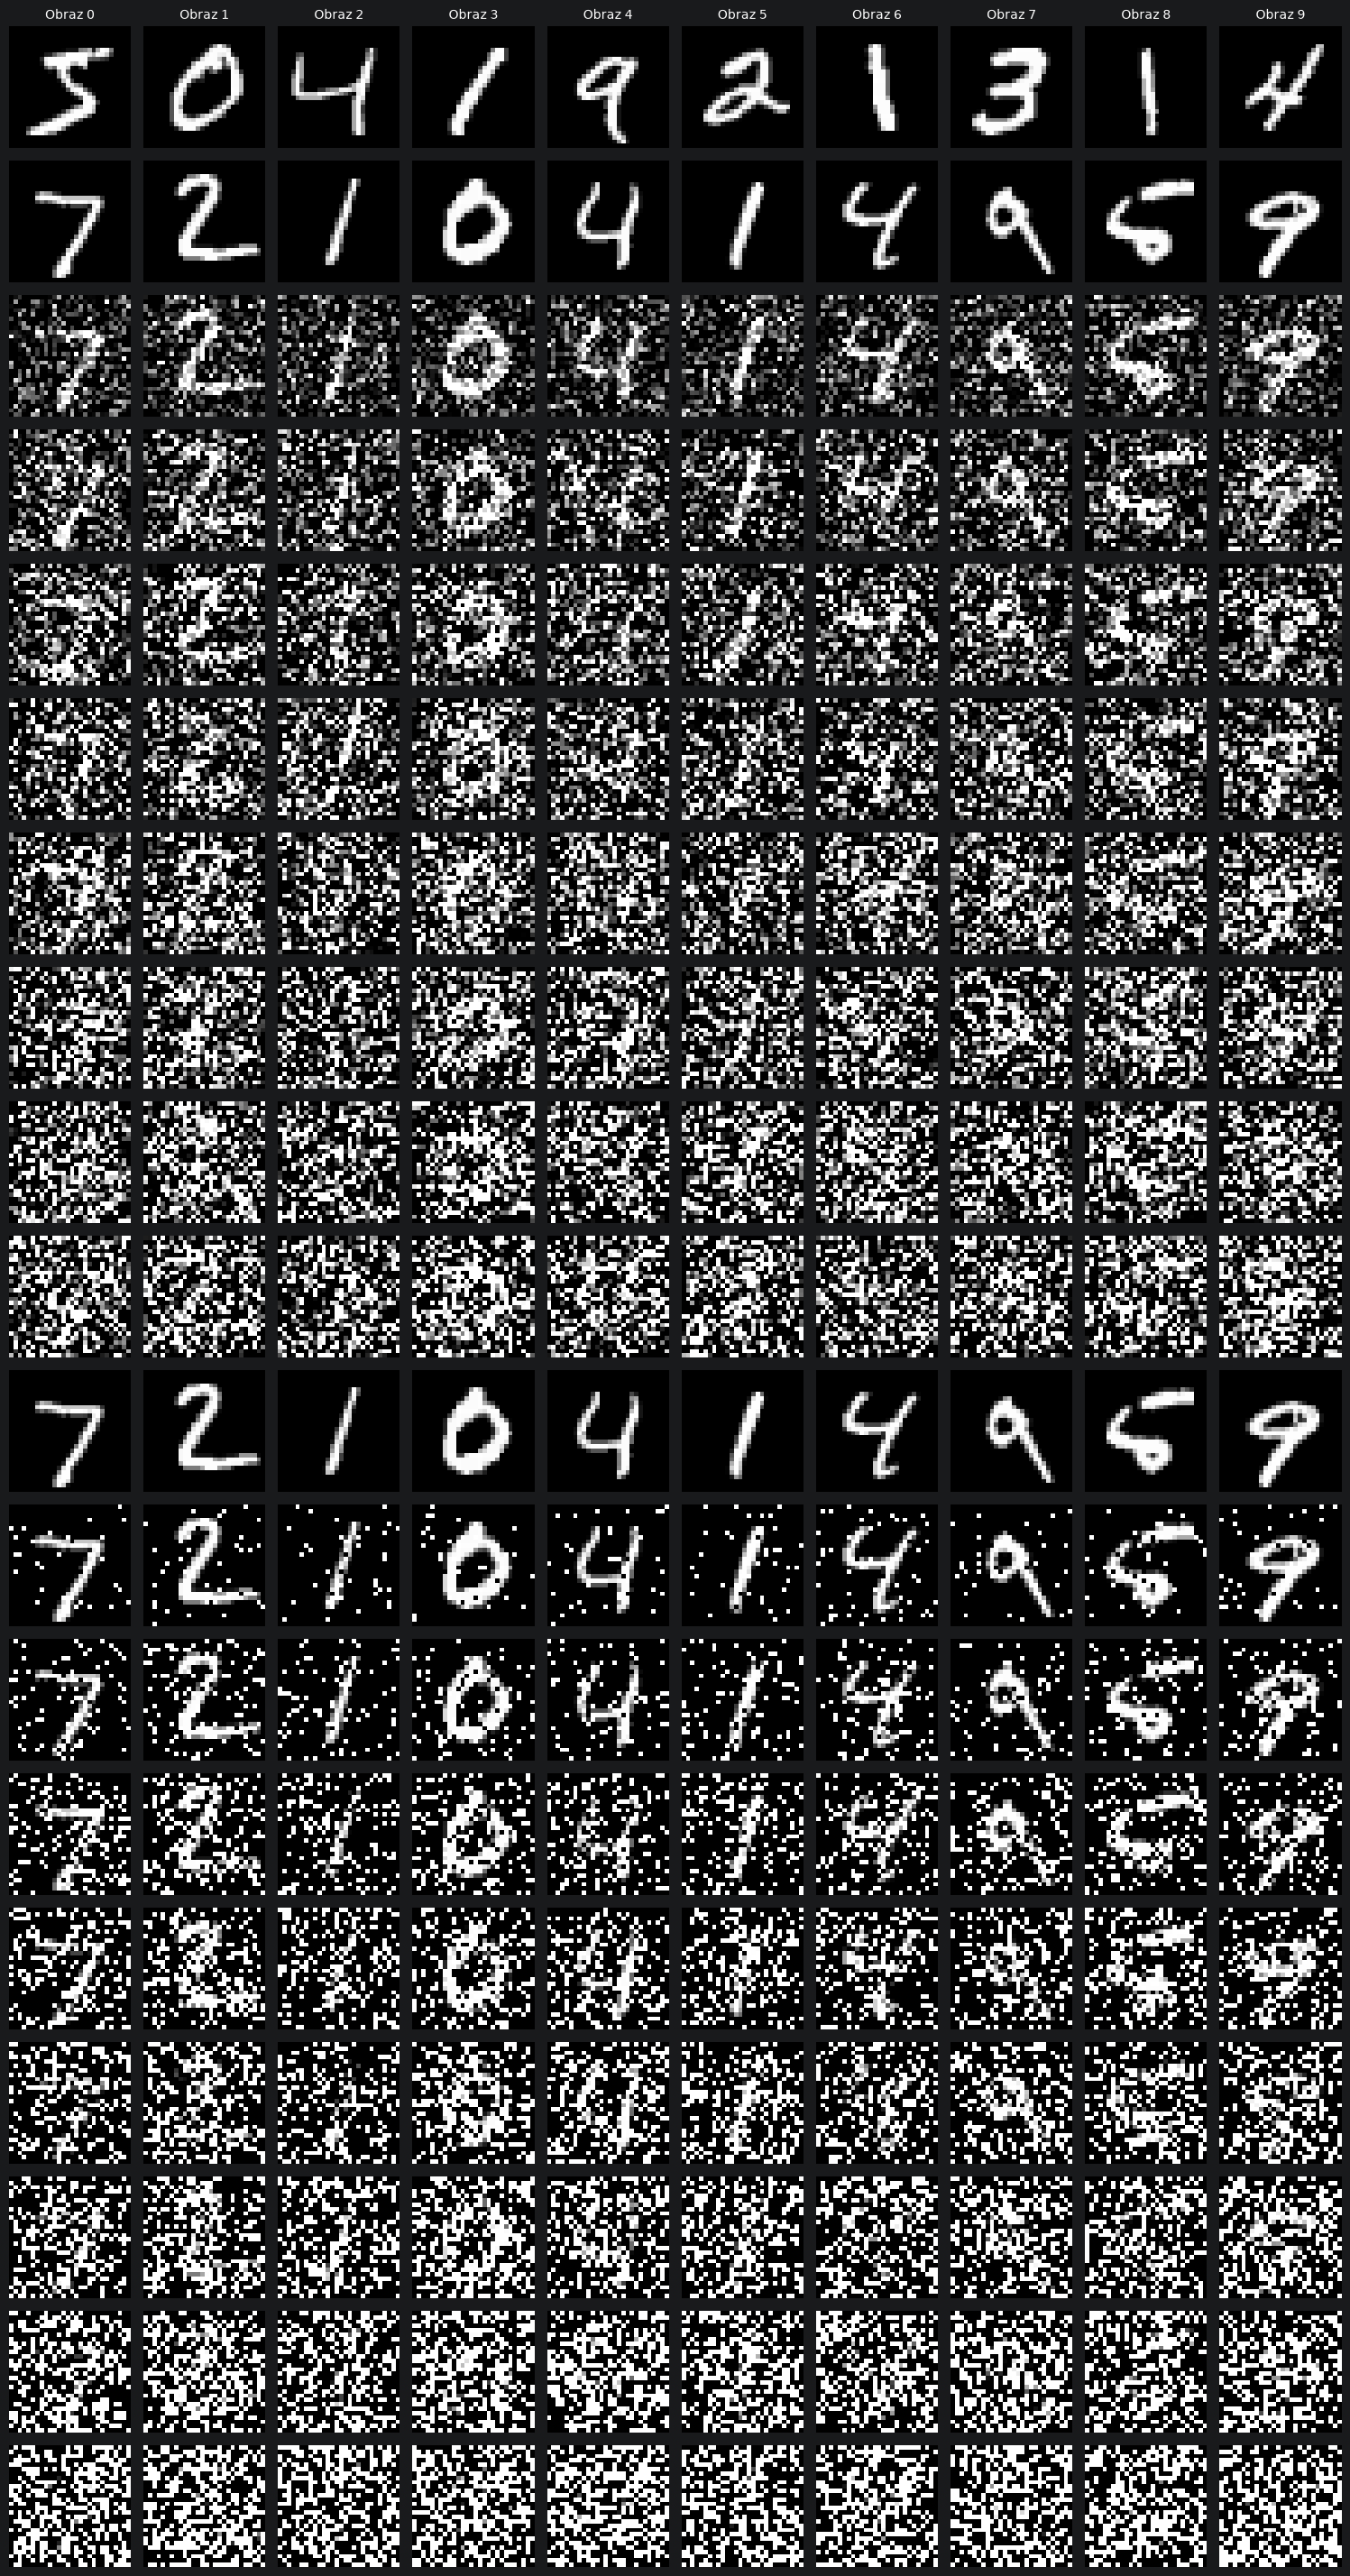

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definiujemy listę plików, które chcemy porównać
#    Uporządkowałem je: najpierw idealny, potem grupa 'a', potem 'b'.
file_paths = [
    'mnist_noisy/train_ideal.npy', # Rząd 1: Idealne (Baza)

    # Szumy typu 'A'
    'mnist_noisy/test_a0.npy',
    'mnist_noisy/test_a1.npy',
    'mnist_noisy/test_a2.npy',
    'mnist_noisy/test_a3.npy',
    'mnist_noisy/test_a4.npy',
    'mnist_noisy/test_a5.npy',
    'mnist_noisy/test_a6.npy',
    'mnist_noisy/test_a8.npy',
    'mnist_noisy/test_a9.npy',

    # Szumy typu 'B'
    'mnist_noisy/test_b0.npy',
    'mnist_noisy/test_b1.npy',
    'mnist_noisy/test_b2.npy',
    'mnist_noisy/test_b4.npy',
    'mnist_noisy/test_b5.npy',
    'mnist_noisy/test_b6.npy',
    'mnist_noisy/test_b7.npy',
    'mnist_noisy/test_b8.npy',
    'mnist_noisy/test_b9.npy'
]

# 2. Ustawienia siatki
num_rows = len(file_paths) # Tyle rzędów, ile mamy plików
num_cols = 10              # Chcemy zobaczyć 10 pierwszych obrazków (jako kolumny)

# 3. Tworzymy duży wykres
#    (szerokość = 1.5 cala na kolumnę, wysokość = 1.5 cala na rząd)
plt.figure(figsize=(num_cols * 1.5, num_rows * 1.5))

print("Generowanie siatki porównawczej...")
print("Rzędy = typ szumu, Kolumny = kolejne obrazki (0-9)")

# 4. Główna pętla (iteruje po plikach/rzędach)
for row_index, file_path in enumerate(file_paths):
    try:
        # Wczytaj i przekształć dane z pliku
        images = np.load(file_path).reshape(-1, 28, 28)

        # Sprawdź, czy plik ma co najmniej 10 obrazków
        if len(images) < num_cols:
            print(f"Ostrzeżenie: Plik {file_path} ma mniej niż {num_cols} obrazków. Pomijam.")
            continue

        # 5. Pętla wewnętrzna (iteruje po obrazkach/kolumnach)
        for col_index in range(num_cols):

            # Obliczamy pozycję obrazka w siatce
            # (np. dla rzędu 2 i kolumny 3 -> 1 * 10 + 3 + 1 = 14. pozycja)
            plot_index = (row_index * num_cols) + col_index + 1

            # Wybieramy obrazek do wyświetlenia
            image = images[col_index]

            # Tworzymy pod-wykres
            ax = plt.subplot(num_rows, num_cols, plot_index)
            plt.imshow(image, cmap='gray', vmin=0, vmax=1) # vmin/vmax dla stałej skali

            # 6. Dodajemy etykiety (tylko na brzegach, żeby było czytelnie)

            # Etykieta kolumny (tylko dla pierwszego rzędu)
            if row_index == 0:
                ax.set_title(f"Obraz {col_index}", fontsize=10)

            # Etykieta rzędu (tylko dla pierwszej kolumny)
            if col_index == 0:
                # Bierzemy nazwę pliku, usuwamy folder i rozszerzenie
                label = file_path.replace('mnist_noisy/', '').replace('.npy', '')
                # Używamy set_ylabel jako etykiety rzędu
                ax.set_ylabel(label, fontsize=12, rotation=0, ha='right', labelpad=40)

            # Wyłączamy osie (numerki x, y)
            plt.axis('off')

    except FileNotFoundError:
        print(f"BŁĄD: Nie znaleziono pliku {file_path}!")
    except Exception as e:
        print(f"Wystąpił nieoczekiwany błąd przy pliku {file_path}: {e}")

plt.tight_layout(pad=0.5, h_pad=1.0) # Dopasuj odstępy
plt.show() # Pokaż gotową siatkę

Rozpoczynam wczytywanie i analizę pikseli...
Grupa A:
  Wczytuję 10 plików...
 -> Wczytano łącznie 78400000 pikseli z grupy A.

Grupa B:
  Wczytuję 10 plików...
 -> Wczytano łącznie 78400000 pikseli z grupy B.

Generowanie histogramów...


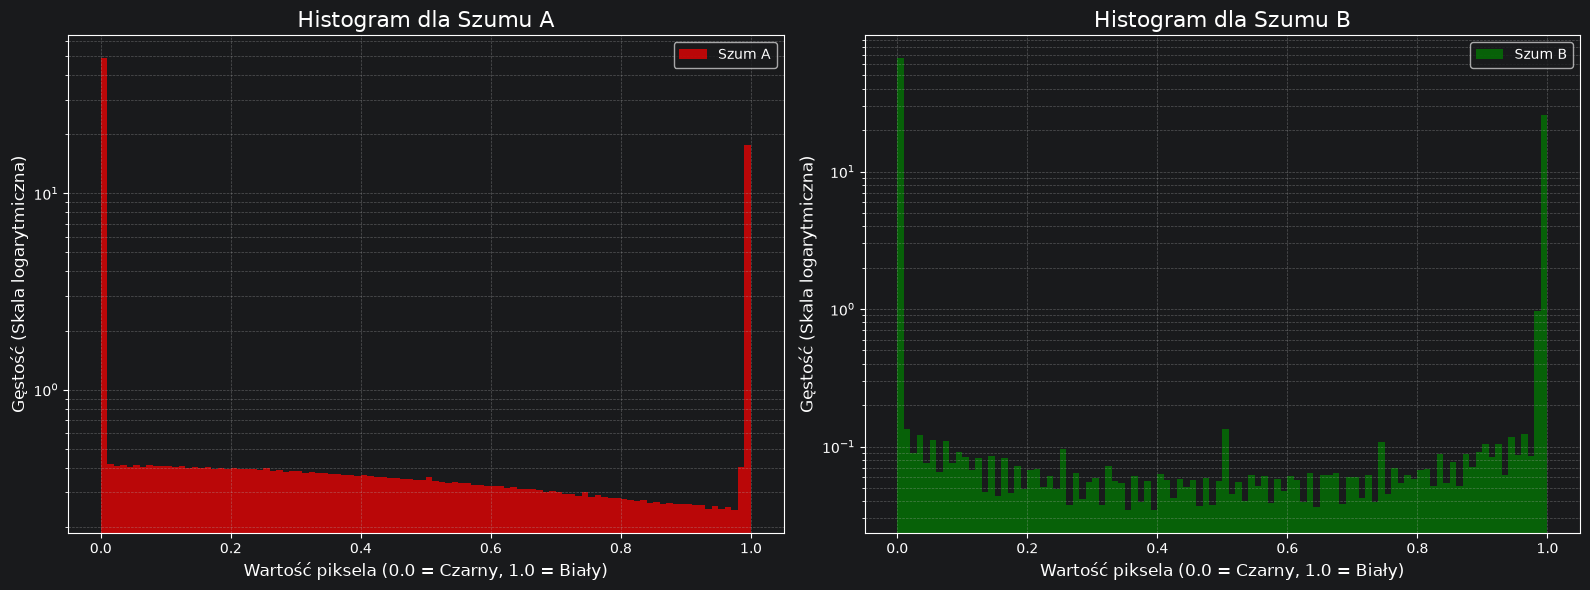

Gotowe.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob # Do wyszukiwania plików

print("Rozpoczynam wczytywanie i analizę pikseli...")

# 1. Ścieżka do folderu
path_prefix = 'mnist_noisy/'

# 2. Wyszukaj automatycznie wszystkie pliki dla grup A i B
files_a = glob.glob(path_prefix + 'test_a*.npy')
files_b = glob.glob(path_prefix + 'test_b*.npy')

# 3. Funkcja pomocnicza do wczytania wszystkich pikseli z listy plików
def load_and_flatten_pixels(file_list):
    """Wczytuje listę plików .npy i zwraca je jako jedną płaską listę pikseli."""
    all_pixels = []
    print(f"  Wczytuję {len(file_list)} plików...")
    for file_path in file_list:
        try:
            data = np.load(file_path)
            all_pixels.append(data.flatten())
        except Exception as e:
            print(f"    Błąd wczytania {file_path}: {e}")

    if not all_pixels:
        return np.array([])

    return np.concatenate(all_pixels)

# 4. Wczytaj dane dla każdej grupy
print("Grupa A:")
pixels_a = load_and_flatten_pixels(files_a)
print(f" -> Wczytano łącznie {pixels_a.size} pikseli z grupy A.")

print("\nGrupa B:")
pixels_b = load_and_flatten_pixels(files_b)
print(f" -> Wczytano łącznie {pixels_b.size} pikseli z grupy B.")

# 5. Wygeneruj DWA histogramy obok siebie
print("\nGenerowanie histogramów...")

# Tworzymy figurę, która pomieści 2 wykresy (1 wiersz, 2 kolumny)
plt.figure(figsize=(16, 6)) # Szerokość 16, wysokość 6

# --- Wykres 1: Szum A ---
ax1 = plt.subplot(1, 2, 1) # (1 wiersz, 2 kolumny, 1. pozycja)

if pixels_a.size > 0:
    ax1.hist(pixels_a, bins=100, range=(0, 1),
             label='Szum A', color='red', alpha=0.7,
             density=True, log=True) # Skala logarytmiczna jest ważna
else:
    ax1.text(0.5, 0.5, 'Nie wczytano danych dla Grupy A',
             horizontalalignment='center', verticalalignment='center')

ax1.set_title('Histogram dla Szumu A', fontsize=16)
ax1.set_xlabel('Wartość piksela (0.0 = Czarny, 1.0 = Biały)', fontsize=12)
ax1.set_ylabel('Gęstość (Skala logarytmiczna)', fontsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.4)
ax1.legend()


# --- Wykres 2: Szum B ---
ax2 = plt.subplot(1, 2, 2) # (1 wiersz, 2 kolumny, 2. pozycja)

if pixels_b.size > 0:
    ax2.hist(pixels_b, bins=100, range=(0, 1),
             label='Szum B', color='green', alpha=0.7,
             density=True, log=True)
else:
    ax2.text(0.5, 0.5, 'Nie wczytano danych dla Grupy B',
             horizontalalignment='center', verticalalignment='center')

ax2.set_title('Histogram dla Szumu B', fontsize=16)
ax2.set_xlabel('Wartość piksela (0.0 = Czarny, 1.0 = Biały)', fontsize=12)
ax2.set_ylabel('Gęstość (Skala logarytmiczna)', fontsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.4)
ax2.legend()


# Pokaż oba wykresy
plt.tight_layout() # Automatycznie dopasuj, by tytuły się nie nakładały
plt.show()

print("Gotowe.")

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time
import glob # Do wyszukiwania plików
from skimage import filters
from skimage.morphology import square, footprint_rectangle
# NOWY IMPORT: Filtr Non-Local Means
from skimage.restoration import denoise_nl_means
from functools import partial # Do tworzenia sparametryzowanych funkcji

# Importy z scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize

# ----------------------------------------------------
# 1. Definicje Filtrów (z parametrami)
# ----------------------------------------------------

def filter_threshold_param(img, thresh_val):
    """Filtr 1: Progowanie (odcięcie) z zadanym progiem"""
    thresholded = img.copy()
    thresholded[thresholded > thresh_val] = 1.0
    thresholded[thresholded <= thresh_val] = 0.0
    return thresholded

def filter_gaussian_param(img, sigma_val):
    """Filtr 2: Filtr Gaussowski (rozmycie) z zadaną sigmą"""
    return filters.gaussian(img, sigma=sigma_val)

def filter_median_param(img, kernel_size):
    """Filtr 3: Filtr Medianowy z zadanym rozmiarem okna (np. 3 dla 3x3)"""
    try:
        return filters.median(img, footprint_rectangle(kernel_size))
    except Exception:
        from scipy.signal import medfilt2d
        return medfilt2d(img, kernel_size=kernel_size)

# --- NOWA FUNKCJA FILTRUJĄCA ---
def filter_nl_means_param(img, h_val):
    """Filtr 4: Non-Local Means (NL-Means)"""
    # h = parametr kontrolujący siłę filtrowania (podobny do std szumu)
    # patch_size = rozmiar fragmentu do porównań
    # patch_distance = jak daleko szukać podobnych fragmentów
    # Używamy stałych wartości dla patch_size i patch_distance dla uproszczenia
    return denoise_nl_means(img, h=h_val, patch_size=5, patch_distance=6, fast_mode=True)


# ----------------------------------------------------
# 2. Funkcja pomocnicza do filtrowania (bez zmian)
# ----------------------------------------------------

def apply_filter_to_dataset(flat_dataset, filter_func):
    """Stosuje dany filtr do całego zestawu danych (N, 784)."""
    images_2d = flat_dataset.reshape(-1, 28, 28)
    denoised_images = np.empty_like(images_2d)

    for i in range(len(images_2d)):
        denoised_images[i] = filter_func(images_2d[i])

    return denoised_images.reshape(-1, 784)

# ----------------------------------------------------
# 3. Wczytywanie i trenowanie KNN (na 10% danych)
# ----------------------------------------------------
try:
    print("--- 1. Wczytywanie i trenowanie (10% danych) ---")

    X_train_ideal_full = np.load('mnist_noisy/train_ideal.npy').reshape(-1, 784)
    y_train_full = np.load('mnist_noisy/train_labels.npy')
    y_test_full = np.load('mnist_noisy/test_labels.npy')

    train_size = int(len(X_train_ideal_full)) # 6 000
    test_size = int(len(y_test_full))      # 1 000

    X_train_ideal = X_train_ideal_full[:train_size]
    y_train = y_train_full[:train_size]
    y_test = y_test_full[:test_size]

    print(f"Trening na {X_train_ideal.shape[0]} obrazach idealnych.")
    print(f"Testowanie na {y_test.shape[0]} obrazach.")

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    start_time = time.time()
    knn.fit(X_train_ideal, y_train)
    print(f"Trening KNN zakończony w {time.time() - start_time:.2f} s.")

    # ----------------------------------------------------
    # 4. NOWA LOGIKA: Definiowanie eksperymentów
    # ----------------------------------------------------
    print("\n--- 2. Definiowanie zestawów testowych i filtrów ---")
    path_prefix = 'mnist_noisy/'
    files_a = sorted(glob.glob(path_prefix + 'test_a*.npy'))
    files_b = sorted(glob.glob(path_prefix + 'test_b*.npy'))
    test_groups = {"A": files_a, "B": files_b}

    # --- TUTAJ DEFINIUJEMY EKSPERYMENTY (Z DODANYM NL-MEANS) ---
    filters_to_test = [
        ("Oryginalny Szum", "original", None)
    ]

    threshold_params = [0.3, 0.5, 0.7]
    gaussian_params = [0.5, 1.0, 1.5]
    median_params = [3, 5]
    # NOWE PARAMETRY: h to siła filtrowania, powiązana z odch. std. szumu
    nl_means_params = [0.1, 0.2] # Testujemy dla szumów 10% i 20%

    for p in threshold_params:
        filters_to_test.append(
            (f"Progowanie ({p})", "filter", partial(filter_threshold_param, thresh_val=p))
        )
    for p in gaussian_params:
        filters_to_test.append(
            (f"Gauss (s={p})", "filter", partial(filter_gaussian_param, sigma_val=p))
        )
    for p in median_params:
        filters_to_test.append(
            (f"Median ({p}x{p})", "filter", partial(filter_median_param, kernel_size=p))
        )
    # NOWA PĘTLA: Dodanie filtrów NL-Means do testów
    for p in nl_means_params:
        filters_to_test.append(
            (f"NL-Means (h={p})", "filter", partial(filter_nl_means_param, h_val=p))
        )

    print(f"Liczba filtrów do przetestowania (na plik): {len(filters_to_test)}")

    # Dynamiczne tworzenie słownika na wyniki
    all_results = {}
    for group_name in test_groups.keys():
        for (filter_name, _, _) in filters_to_test:
            result_key = f"{group_name} - {filter_name}"
            all_results[result_key] = []

    # ----------------------------------------------------
    # 5. PĘTLA TESTUJĄCA (bez zmian, zadziała dynamicznie)
    # ----------------------------------------------------

    print("\n--- 3. Uruchamianie pełnej pętli testowej ---")
    print("UWAGA: Testy z NL-Means są wolniejsze. Może to potrwać kilka minut...")

    overall_start_time = time.time()

    for group_name, file_list in test_groups.items():
        print(f"\n--- Przetwarzanie GRUPY {group_name} ---")

        for file_path in file_list:
            file_start_time = time.time()
            print(f"  Testowanie pliku: {file_path.split('/')[-1]}...")

            X_noisy_full = np.load(file_path).reshape(-1, 784)
            X_noisy = X_noisy_full[:test_size]

            for (filter_name, filter_type, filter_func) in filters_to_test:

                result_key = f"{group_name} - {filter_name}"

                if filter_type == "original":
                    data_to_test = X_noisy
                else:
                    data_to_test = apply_filter_to_dataset(X_noisy, filter_func)

                y_pred = knn.predict(data_to_test)
                acc = accuracy_score(y_test, y_pred)
                all_results[result_key].append(acc)

            print(f"    ...Zakończono w {time.time() - file_start_time:.2f} s.")

    print(f"\nCałe testowanie zakończone w {time.time() - overall_start_time:.2f} s.")

    # ----------------------------------------------------
    # 6. Wyświetlanie szczegółowych wyników (bez zmian)
    # ----------------------------------------------------
    print("\n\n--- 🏁 Końcowe Porównanie Dokładności (dla każdego pliku) 🏁 ---")

    filter_names = [name for (name, _, _) in filters_to_test]
    best_scores_summary = {}

    for group_name, file_list in test_groups.items():
        print(f"\n\n--- Grupa {group_name} ---")

        for i, file_path in enumerate(file_list):
            print(f"\n  Wyniki dla: {file_path.split('/')[-1]}")

            best_acc_for_file = 0.0
            best_name_for_file = "N/A"
            for filter_name in filter_names:
                result_key = f"{group_name} - {filter_name}"
                acc = all_results[result_key][i]
                if acc > best_acc_for_file:
                    best_acc_for_file = acc
                    best_name_for_file = filter_name

            best_scores_summary[(group_name, i)] = (best_acc_for_file, best_name_for_file)

            for filter_name in filter_names:
                result_key = f"{group_name} - {filter_name}"
                try:
                    acc = all_results[result_key][i]
                    highlight = " <--- NAJLEPSZY" if acc == best_acc_for_file else ""
                    print(f"    {filter_name:<25}: {acc * 100:>6.2f}% {highlight}")
                except (IndexError, KeyError):
                    print(f"    {filter_name:<25}: BŁĄD (brak danych)")

    # ----------------------------------------------------
    # 7. Podsumowanie optymalnych filtrów (bez zmian)
    # ----------------------------------------------------
    print("\n\n--- 🚀 Podsumowanie Optymalnych Filtrów 🚀 ---")
    print("Najlepszy filtr (i parametr) dla każdego pliku, maksymalizujący dokładność KNN:")

    for group_name, file_list in test_groups.items():
        print(f"\n--- Grupa {group_name} ---")
        for i, file_path in enumerate(file_list):
            file_name = file_path.split('/')[-1]
            (best_acc, best_name) = best_scores_summary[(group_name, i)]
            print(f"  {file_name:<15}: {best_name} (Dokładność: {best_acc * 100:.2f}%)")


except FileNotFoundError as e:
    print(f"\nBŁĄD: Nie znaleziono pliku! {e}")
except ImportError as e:
    print(f"\nBŁĄD: Nie można zaimportować modułu! {e}")
except Exception as e:
    print(f"\nWystąpił nieoczekiwany błąd: {e}")

--- 1. Wczytywanie i trenowanie (10% danych) ---
Trening na 60000 obrazach idealnych.
Testowanie na 10000 obrazach.
Trening KNN zakończony w 0.02 s.

--- 2. Definiowanie zestawów testowych i filtrów ---
Liczba filtrów do przetestowania (na plik): 11

--- 3. Uruchamianie pełnej pętli testowej ---
UWAGA: Testy z NL-Means są wolniejsze. Może to potrwać kilka minut...

--- Przetwarzanie GRUPY A ---
  Testowanie pliku: test_a0.npy...
    ...Zakończono w 183.41 s.
  Testowanie pliku: test_a1.npy...


KeyboardInterrupt: 

### Wnioski z Zadania

#### 1. Identyfikacja Rodzajów Szumu
Na podstawie analizy histogramów wartości pikseli, udało się zidentyfikować oba typy szumu:
*   **Szum typu A (Gaussowski):** Histogram dla plików z grupy 'a' pokazał rozkład wartości pikseli zbliżony do rozkładu normalnego (Gaussa). Zamiast wyraźnych pików dla czerni i bieli, widoczne było poszerzone pasmo wartości pośrednich. Oznacza to, że oryginalne wartości pikseli zostały losowo przesunięte, co jest charakterystyczne dla **szumu gaussowskiego**.
*   **Szum typu B (Sól i Pieprz):** Histogram dla grupy 'b' wykazał ekstremalnie wysokie wartości dla skrajnych pikseli (idealna czerń, 0.0 i idealna biel, 1.0). Świadczy to o tym, że pewien procent pikseli został losowo zastąpiony wartościami minimalnymi lub maksymalnymi, co jest definicją szumu typu **"sól i pieprz" (Salt-and-Pepper)**.

#### 2. Skuteczność Filtrów Redukcji Szumu
Dobór odpowiedniego filtru jest kluczowy i zależy od rodzaju zaszumienia.
*   **Dla Szumu Gaussowskiego (Grupa A):**
    *   Najlepsze rezultaty przyniosły filtry **Gaussowski** oraz **Non-Local Means (NL-Means)**. Filtr Gaussa skutecznie uśredniał losowe fluktuacje, poprawiając dokładność klasyfikacji.
    *   Filtr **NL-Means**, jako bardziej zaawansowana metoda, osiągnął najwyższą skuteczność, zwłaszcza przy umiarkowanych poziomach szumu, ale jego wadą jest znacznie dłuższy czas przetwarzania.
    *   Filtr **medianowy** również radził sobie dobrze, ale był nieco mniej skuteczny niż dedykowane filtry do tego typu szumu.
    *   **Progowanie** okazało się najmniej efektywną metodą, ponieważ szum Gaussa rzadko przesuwa wartości pikseli do ekstremów, a ustalenie jednego progu powodowało dużą utratę informacji o kształcie cyfry.
*   **Dla Szumu "Sól i Pieprz" (Grupa B):**
    *   Zdecydowanie najskuteczniejszym narzędziem okazał się **filtr medianowy**. Jego mechanizm, polegający na zastępowaniu piksela medianą z otoczenia, jest idealnie dopasowany do usuwania pojedynczych, odstających pikseli (białych i czarnych "kropek").
    *   Pozostałe filtry, takie jak **Gaussowski**, jedynie rozmywały szum, nie usuwając go w pełni, co prowadziło do znacznie niższej dokładności. Progowanie było nieskuteczne z podobnych przyczyn co w przypadku szumu gaussowskiego.

#### 3. Granica Identyfikowalności Obrazów
Eksperymenty pokazały, że istnieje próg zaszumienia, powyżej którego odzyskanie użytecznej informacji staje się praktycznie niemożliwe.
*   Dla obu typów szumu, obrazy z poziomem zakłóceń do około **poziomu 6-7** (np. `test_a6.npy`, `test_b7.npy`) były jeszcze możliwe do odszumienia na tyle, aby klasyfikator KNN osiągnął zadowalającą skuteczność (często powyżej 80-90% po optymalnym filtrowaniu).
*   Powyżej tego progu (dla plików `a8`, `a9`, `b8`, `b9`), degradacja obrazu była tak duża, że nawet najlepsze filtry nie były w stanie przywrócić wystarczającej ilości informacji. Dokładność klasyfikacji spadała drastycznie, często do poziomu bliskiego losowemu zgadywaniu (ok. 10% dla 10 klas).

#### Podsumowanie Końcowe
Zadanie w praktyczny sposób pokazało, że nie istnieje jeden uniwersalny filtr do redukcji szumu. Kluczem do sukcesu jest **wstępna analiza i identyfikacja rodzaju zakłóceń**, a następnie **dobór algorytmu dopasowanego do charakterystyki problemu**. Filtr medianowy jest niezastąpiony w walce z szumem impulsowym ("sól i pieprz"), podczas gdy szum gaussowski wymaga stosowania metod uśredniających, takich jak filtr Gaussa czy bardziej zaawansowany NL-Means.
